# Importing Dataset From Kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("palvinder2006/zepto-inventory-dataset")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

Path to dataset files: /home/hitman/.cache/kagglehub/datasets/palvinder2006/zepto-inventory-dataset/versions/2
Files: ['zepto_v2.csv', 'zepto_v1.xlsx']


In [4]:
df = pd.read_csv(os.path.join(path, "zepto_v2.csv"), encoding="latin1")

In [5]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


# Analysis Report by Ydata Profile Report

In [6]:
from ydata_profiling import ProfileReport

In [7]:
profile = ProfileReport(df, title="Report")

# Save the report to an HTML file
profile.to_file("ydata_Report_zepto.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 2093.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
df.duplicated().value_counts()

False    3730
True        2
Name: count, dtype: int64

In [9]:
df.drop_duplicates()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250
...,...,...,...,...,...,...,...,...,...
3727,Health & Hygiene,Stayfree Secure Dry Cover Extra Large Sanitary...,4200,2,0,4100,406,True,7
3728,Health & Hygiene,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,10500,15,0,8900,100,True,100
3729,Health & Hygiene,Whisper Bindazzz Night Sanitary Pads XL Plus,18500,0,0,18500,870,True,15
3730,Health & Hygiene,Fine Life Cotton Balls,6000,0,0,6000,50,True,50


In [10]:
df.shape

(3732, 9)

In [11]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [12]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')

# Feature Engineering

In [13]:
# Convert prices from Paise to Rupees
df['mrp'] = df['mrp'] / 100
df['discountedSellingPrice'] = df['discountedSellingPrice'] / 100

# Create new features
df['discountAmount'] = df['mrp'] - df['discountedSellingPrice']
df['revenue'] = df['discountedSellingPrice'] * df['quantity']
df['pricePerGram'] = df['discountedSellingPrice'] / df['weightInGms'].replace(0, 1)

In [14]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,discountAmount,revenue,pricePerGram
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,4.0,21.0,0.021000
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1,7.0,35.0,0.035000
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1,8.0,43.0,0.741379
3,Fruits & Vegetables,Coriander Leaves,20.0,15,3,17.0,100,False,100,3.0,1700.0,0.170000
4,Fruits & Vegetables,Ladies Finger,14.0,14,3,12.0,250,False,250,2.0,3000.0,0.048000


# EDA

## Visualizations

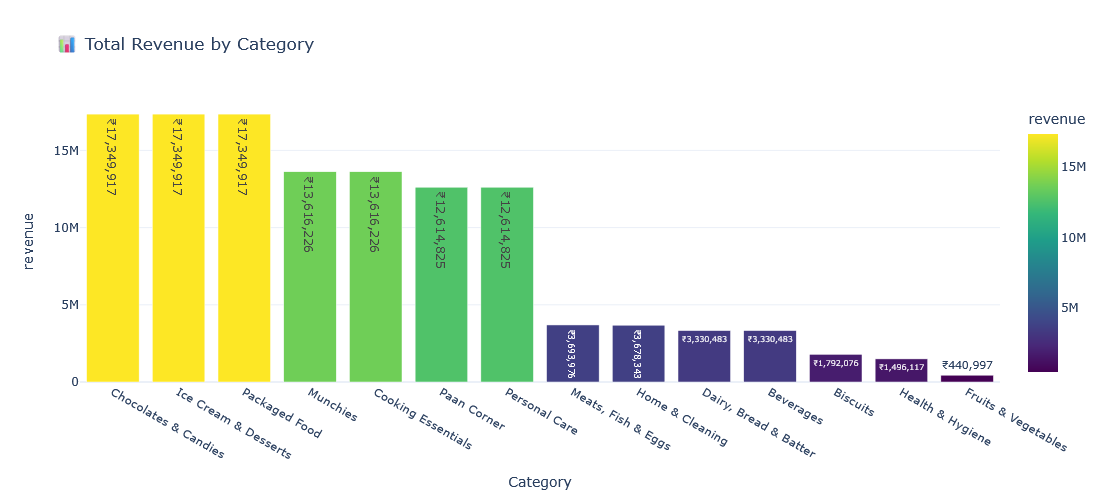

In [15]:
# Revenue by Category
revenue_cat = df.groupby('Category')['revenue'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    revenue_cat,
    x='Category', y='revenue',
    title='📊 Total Revenue by Category',
    color='revenue', color_continuous_scale='Viridis',
    text='revenue'
)

fig.update_traces(texttemplate='₹%{text:,.0f}', textposition='auto')
fig.update_layout(template='plotly_white', hovermode='x unified', height=500)
fig.show()

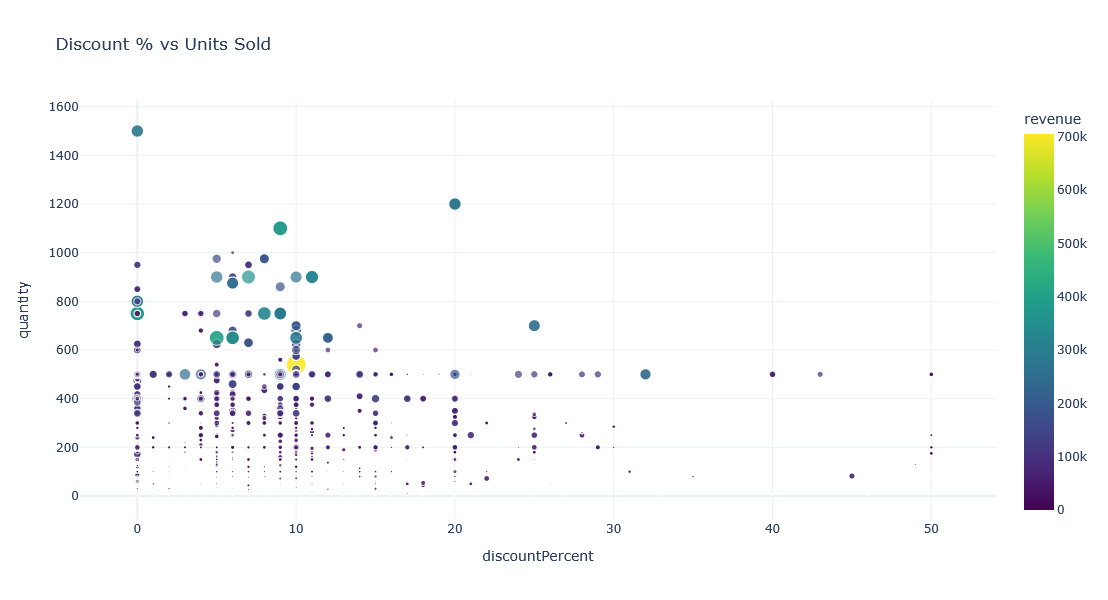

In [16]:
# Discount vs Demand Analysis
fig = px.scatter(
    df, x='discountPercent', y='quantity',
    color='revenue', size='revenue',
    hover_data=['name', 'Category'],
    title='Discount % vs Units Sold',
    color_continuous_scale='Viridis'
)

fig.update_layout(template='plotly_white', height=600)
fig.show()

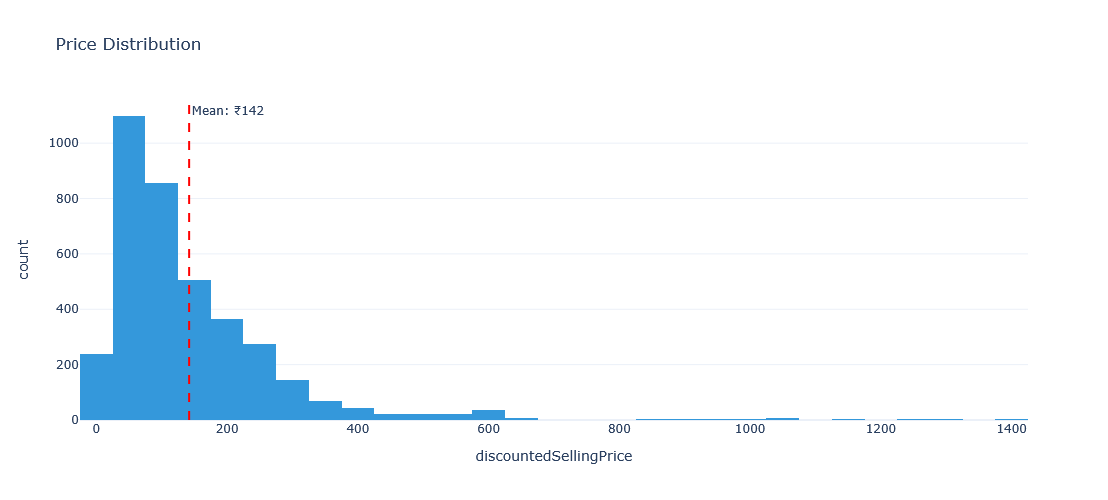

In [17]:
# Price Distribution
fig = px.histogram(
    df, x='discountedSellingPrice',
    nbins=50,
    title=' Price Distribution',
    color_discrete_sequence=['#3498db']
)

mean_price = df['discountedSellingPrice'].mean()
fig.add_vline(x=mean_price, line_dash='dash', line_color='red',
              annotation_text=f'Mean: ₹{mean_price:.0f}')

fig.update_layout(template='plotly_white', height=500)
fig.show()

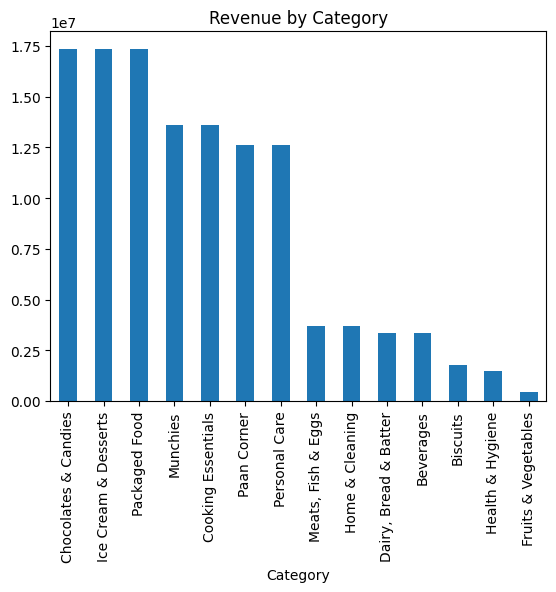

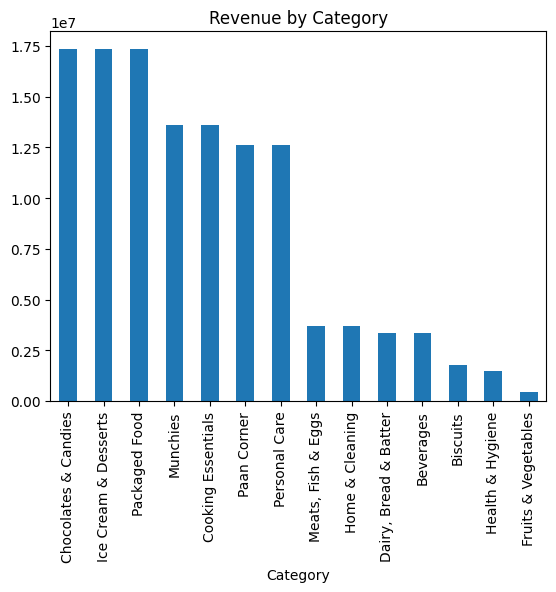

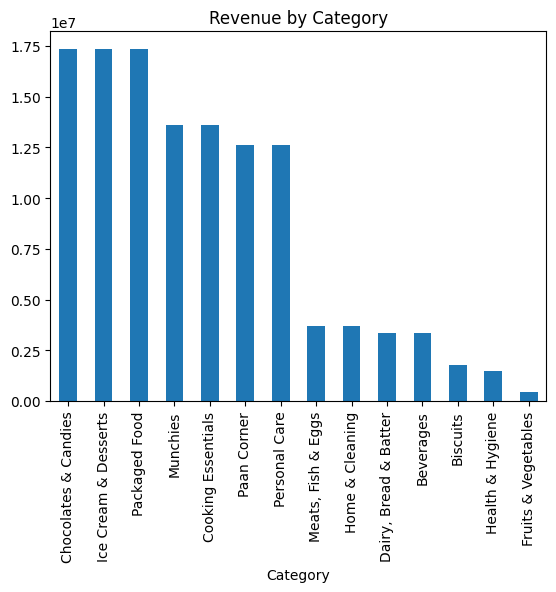

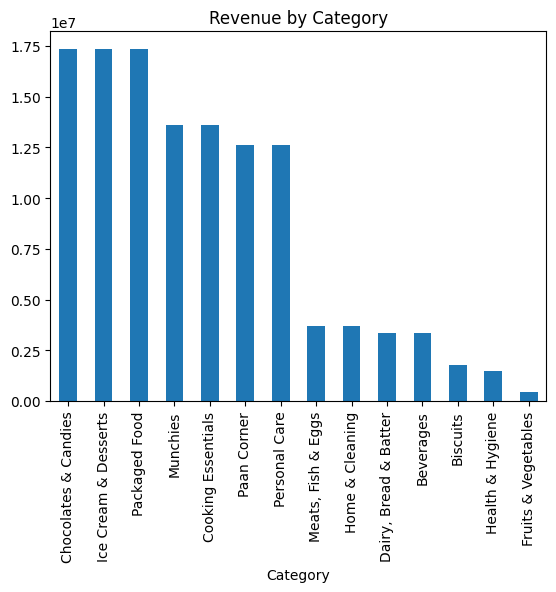

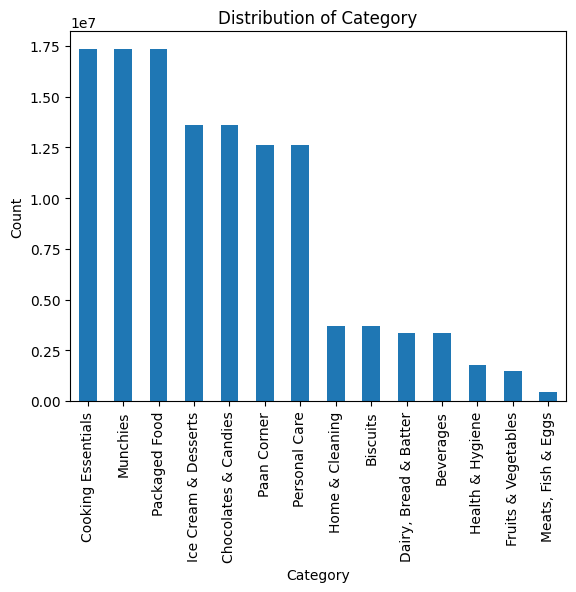

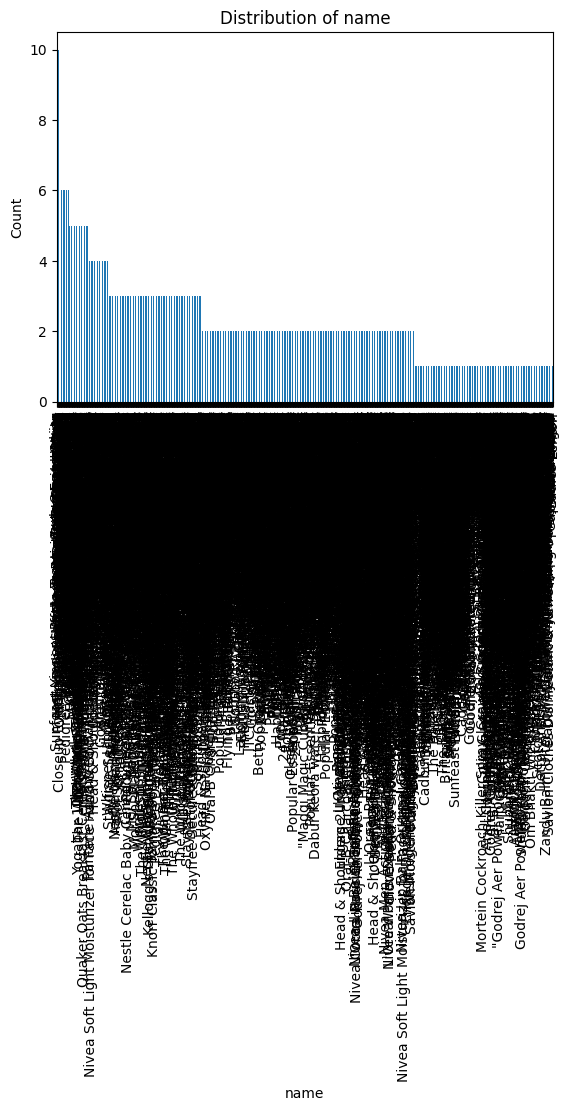

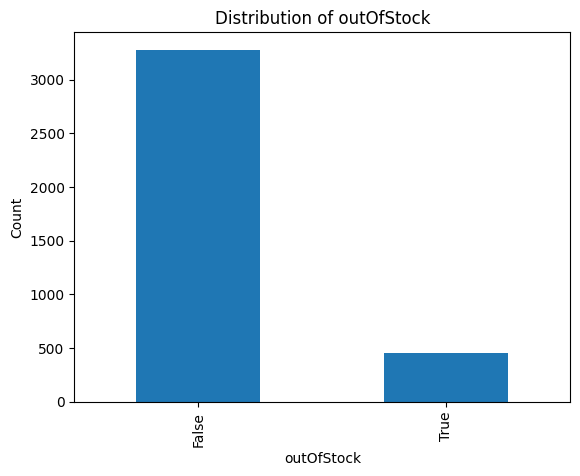

In [44]:
category_cols = ["Category","name","outOfStock"]

for cols in df.columns:
    if cols in category_cols:
        col_df = df[cols]
        
        if col_df.dtype == 'bool' or col_df.dtype == 'object':
            col_df.value_counts().plot(kind="bar")
        else:
            plt.hist(col_data, bins=20)

        plt.xlabel(f"{cols}")
        plt.ylabel("Count")
        plt.title(f"Distribution of {cols}")
        plt.show()


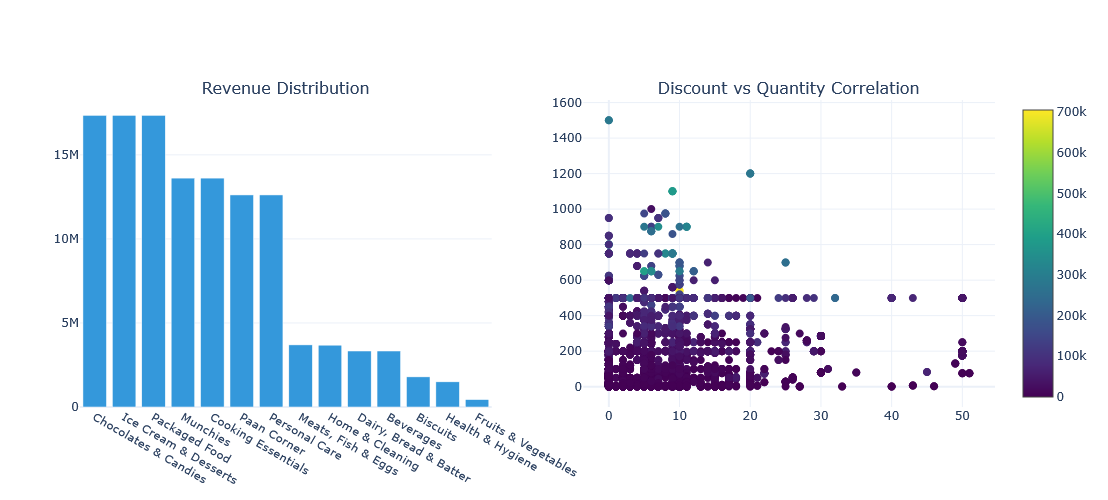

In [45]:

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'bar'}, {'type':'scatter'}]],
    subplot_titles=('Revenue Distribution', 'Discount vs Quantity Correlation')
)

# Revenue chart
fig.add_trace(
    go.Bar(x=revenue_cat.index, y=revenue_cat.values, name='Revenue', marker_color='#3498db'),
    row=1, col=1
)

# Scatter plot
fig.add_trace(
    go.Scatter(
        x=df['discountPercent'],
        y=df['quantity'],
        mode='markers',
        name='Products',
        marker=dict(size=8, color=df['revenue'], colorscale='Viridis', showscale=True)
    ),
    row=1, col=2
)

fig.update_layout(height=500, showlegend=False, template='plotly_white')
fig.show()

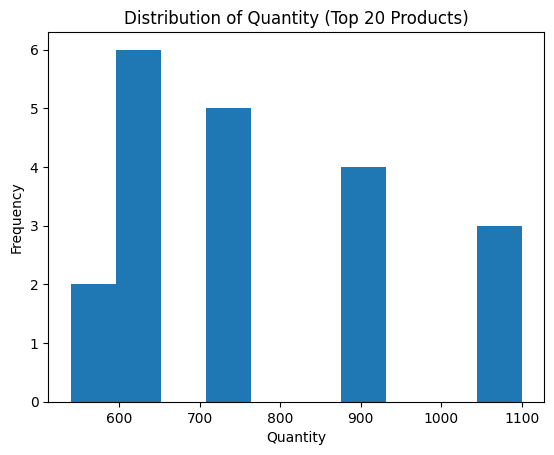

In [46]:
top20 = df.sort_values(by="revenue", ascending=False).head(20)

plt.figure()
plt.hist(top20["quantity"], bins=10)
plt.title("Distribution of Quantity (Top 20 Products)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

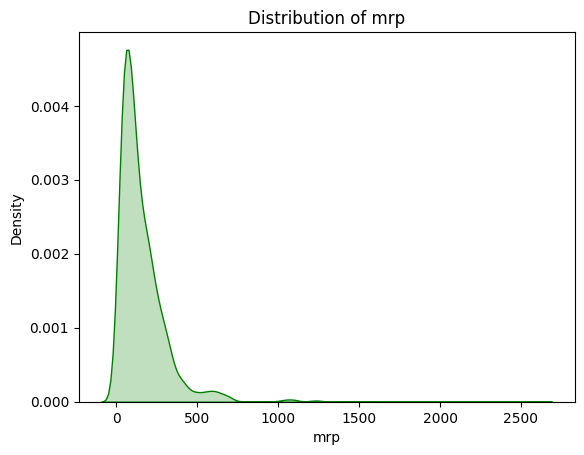

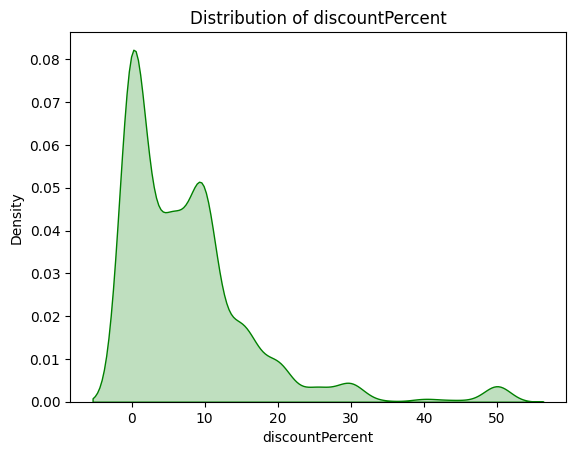

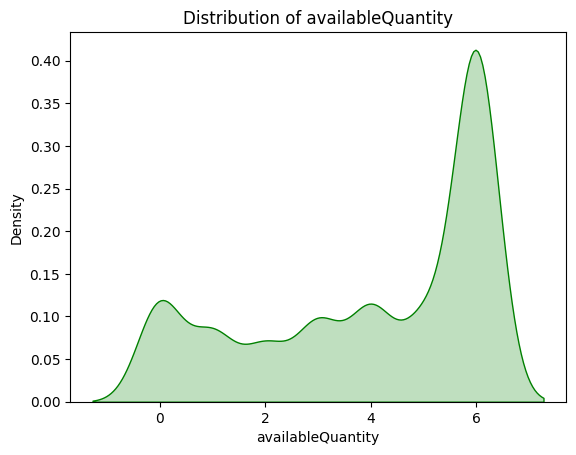

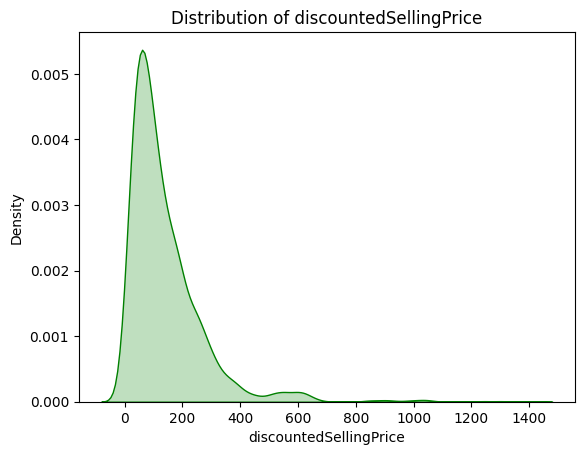

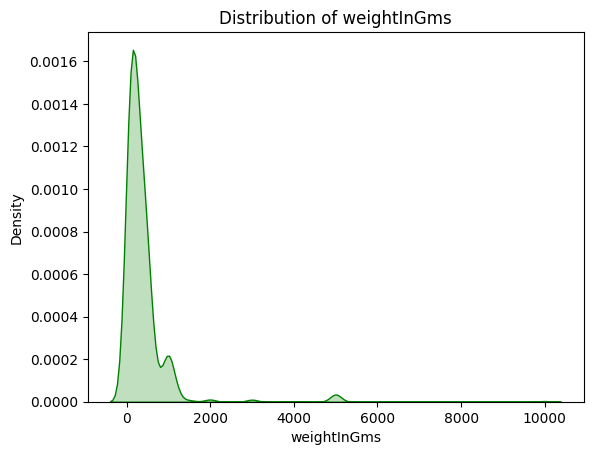

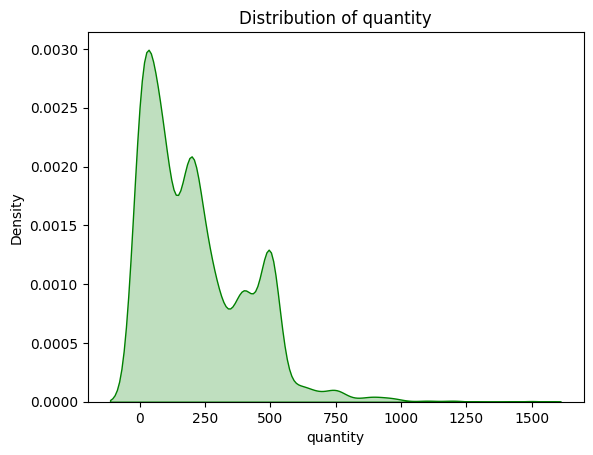

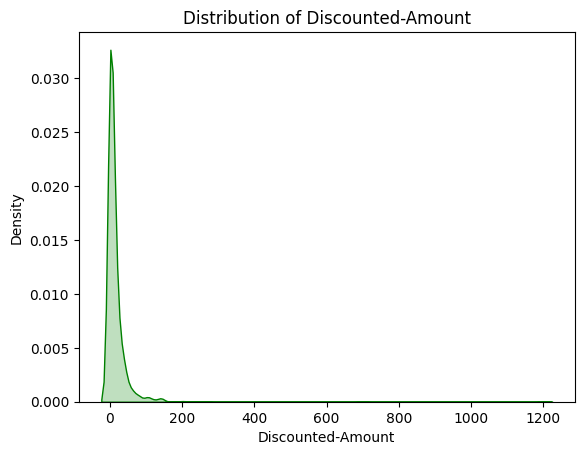

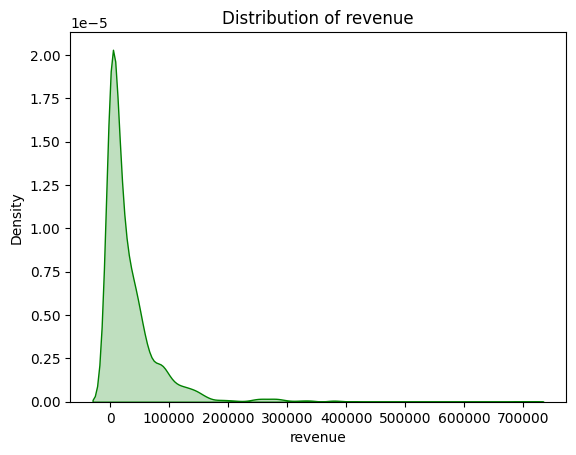

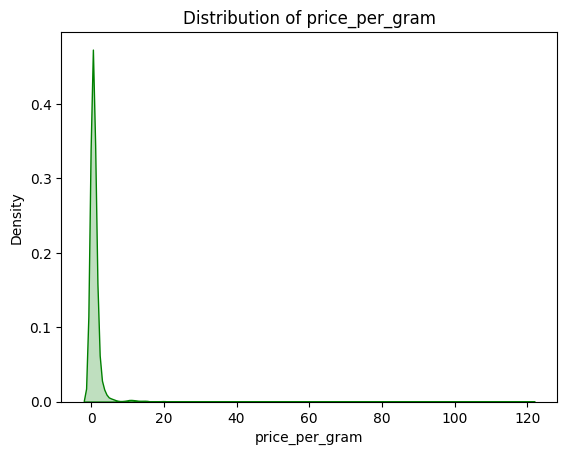

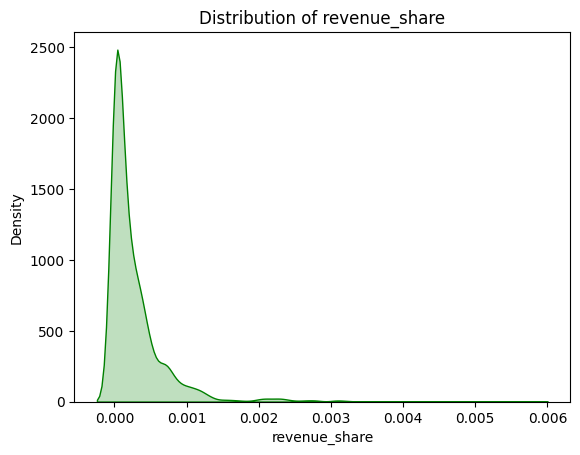

In [79]:
numerical_cols = [col for col in df.columns if col not in category_cols]
numerical_cols

for cols in numerical_cols:
    plt.figure()
    sns.kdeplot(df[cols], fill=True,color="green")
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Density")
    plt.show()

## Average discount per category

In [80]:
# Average discount per category
avg_discount = df.groupby("Category")["discountPercent"].mean().reset_index()

avg_discount

,Category,discountPercent
0,Beverages,7.155039
1,Biscuits,8.244898
2,Chocolates & Candies,8.324742
3,Cooking Essentials,7.163424
4,"Dairy, Bread & Batter",7.155039
5,Fruits & Vegetables,15.462366
6,Health & Hygiene,8.051546
7,Home & Cleaning,5.675258
8,Ice Cream & Desserts,8.324742
9,"Meats, Fish & Eggs",11.031746


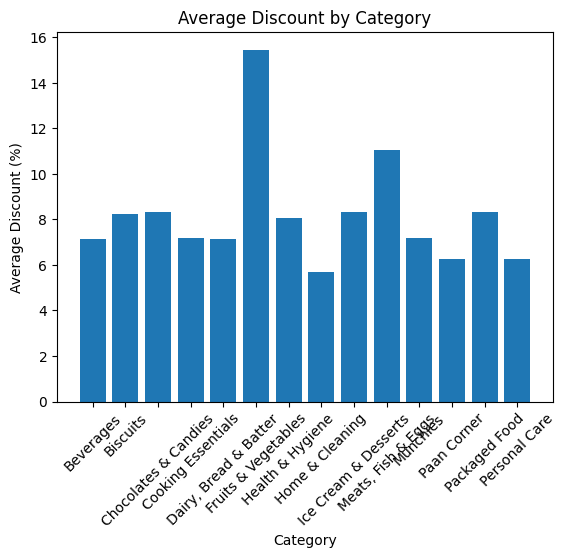

In [81]:
plt.figure()
plt.bar(avg_discount["Category"], avg_discount["discountPercent"])
plt.xticks(rotation=45)
plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.show()

## Average Price per Category¶

In [83]:
avg_price_category = df.groupby("Category")["discountedSellingPrice"].mean().reset_index()
avg_price_category

,Category,discountedSellingPrice
0,Beverages,103.728682
1,Biscuits,52.779592
2,Chocolates & Candies,141.077320
3,Cooking Essentials,140.826848
4,"Dairy, Bread & Batter",103.728682
5,Fruits & Vegetables,39.838710
6,Health & Hygiene,145.855670
7,Home & Cleaning,141.448454
8,Ice Cream & Desserts,141.077320
9,"Meats, Fish & Eggs",164.095238


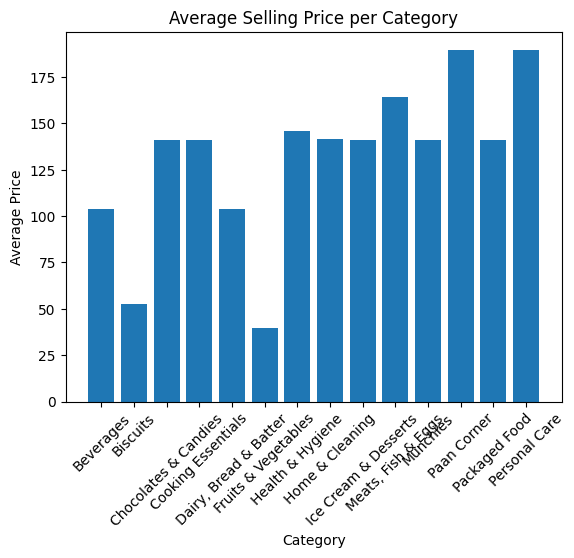

In [84]:

plt.figure()
plt.bar(avg_price_category["Category"], avg_price_category["discountedSellingPrice"])
plt.xticks(rotation=45)
plt.title("Average Selling Price per Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

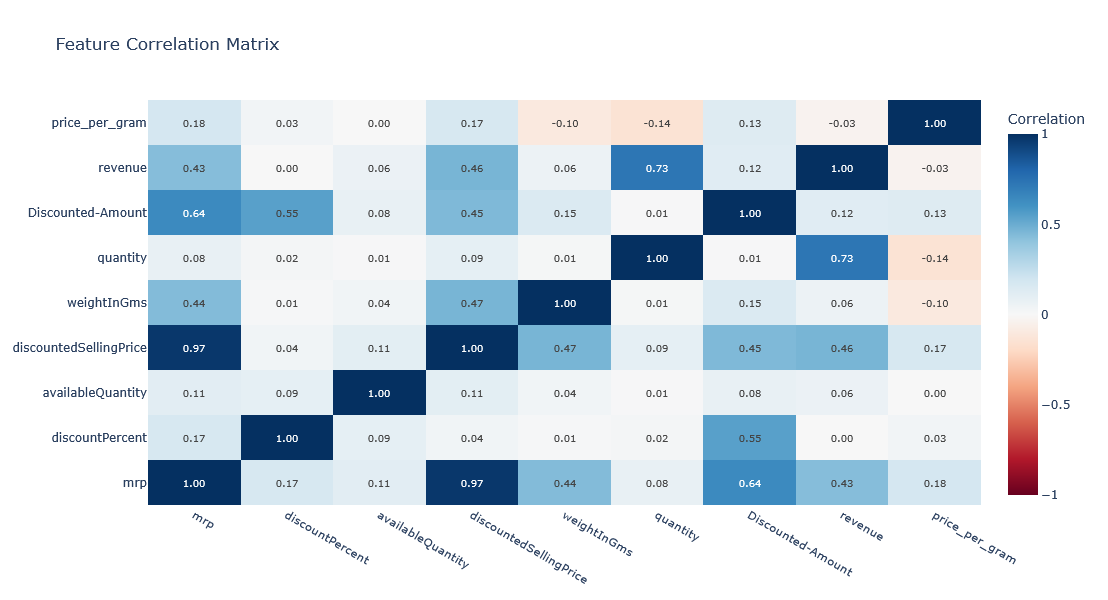

In [47]:

# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=corr_matrix.values,
    texttemplate='%{text:.2f}',
    textfont={"size": 10},
    colorbar=dict(title="Correlation")
))

fig.update_layout(title='Feature Correlation Matrix', height=600, width=700)
fig.show()

In [18]:
from ipywidgets import Dropdown, interact

def filter_by_category(category):
    filtered = df[df['Category'] == category]
    return filtered.describe()

interact(filter_by_category, category=df['Category'].unique())

interactive(children=(Dropdown(description='category', options=('Fruits & Vegetables', 'Cooking Essentials', '…

<function __main__.filter_by_category(category)>

# Problems

## Problem 1: Which products are at risk of stock-out?
* Products with low available quantity but high demand may go out of stock → loss of revenue.

Conclusion
* Inventory is not aligned with demand → high stockout risk

In [39]:
# Sort by available quantity (ascending) and demand (quantity)
stock_risk = df.sort_values(by=["availableQuantity", "quantity"], ascending=[True, False])
stock_risk[["name", "availableQuantity", "quantity"]].head(25)

,name,availableQuantity,quantity
1753,Del Monte Original Blend Tomato Ketchup Pouch,0,950
2141,Del Monte Original Blend Tomato Ketchup Pouch,0,950
2529,Del Monte Original Blend Tomato Ketchup Pouch,0,950
3629,Comfort After Wash Fabric Conditioner Lily Fresh,0,860
3076,Dettol Original Liquid Handwash Refill,0,750
3420,Dettol Original Liquid Handwash Refill,0,750
571,Ching's Secret Veg Hakka Noodles,0,600
1085,Ching's Secret Veg Hakka Noodles,0,600
1736,Ching's Secret Veg Hakka Noodles,0,600
2124,Ching's Secret Veg Hakka Noodles,0,600


### Stock-Out Risk

Products with low inventory but high demand face stockout risk.

In [19]:

# Stock-out risk analysis
stock_risk = df[df['availableQuantity'] < df['quantity']].copy()

# Show top at-risk products
print('\n Top 10 At-Risk Products:')
display(stock_risk[['name', 'Category', 'availableQuantity', 'quantity']].head(10)
        .style.background_gradient(subset=['quantity'], cmap='Reds'))


 Top 10 At-Risk Products:


,name,Category,availableQuantity,quantity
3,Coriander Leaves,Fruits & Vegetables,3,100
4,Ladies Finger,Fruits & Vegetables,3,250
6,Lemon,Fruits & Vegetables,3,200
8,Capsicum Green,Fruits & Vegetables,3,250
9,Chilli Green,Fruits & Vegetables,3,100
10,Banana Robusta,Fruits & Vegetables,3,6
11,Garlic Indian,Fruits & Vegetables,3,100
13,Ginger,Fruits & Vegetables,3,200
14,Spinach,Fruits & Vegetables,3,250
17,Methi,Fruits & Vegetables,3,250


## Problem 2: Are discounts driving revenue?
* Are we giving discounts effectively or wasting margin?

 Conclusion:

 Discounts are not optimized → wasting margin

In [41]:
df[["name", "mrp","discountPercent", "quantity", "revenue"]].sort_values(by="revenue", ascending=False)

,name,mrp,discountPercent,quantity,revenue
877,Praakritik Natural Desi Gir Cow A2 Ghee,1450.0,10,540,704700.0
363,Praakritik Natural Desi Gir Cow A2 Ghee,1450.0,10,540,704700.0
2931,Dove Daily Shine Shampoo,645.0,5,650,397800.0
3275,Dove Daily Shine Shampoo,645.0,5,650,397800.0
2192,Whiskas Kitten (2-12 months) Dry Cat Food Food...,385.0,9,1100,381700.0
...,...,...,...,...,...
2929,Maybelline New York Colossal Kajal Super Black,300.0,8,0,0.0
3273,Maybelline New York Colossal Kajal Super Black,300.0,8,0,0.0
1120,Everest Saffron Kesar,120.0,0,0,0.0
3606,Cherry Blossom Liquid Shoe Polish Neutral,0.0,0,75,0.0


###  Discount Effectiveness

Analyzing whether discounts are driving revenue or just eroding margins

In [20]:
# Discount effectiveness
over_discounted = df[(df['discountPercent'] > 15) & (df['quantity'] < 5)].sort_values('discountPercent', ascending=False)


print('\n Over-Discounted Products (High discount, Low sales):')
display(over_discounted[['name', 'discountPercent', 'quantity', 'revenue']].head(10))


 Over-Discounted Products (High discount, Low sales):


,name,discountPercent,quantity,revenue
517,Borges Extra Light Olive Oil Bottle,46,2,2798.0
1031,Borges Extra Light Olive Oil Bottle,46,2,2798.0
1935,Kelloggs Chocos - Moons & Stars,40,1,396.0
1547,Kelloggs Chocos - Moons & Stars,40,1,396.0
2323,Kelloggs Chocos - Moons & Stars,40,1,396.0
1182,Epigamia Almond Milk Unsweetened Dairy Free,33,1,199.0
1311,Epigamia Almond Milk Unsweetened Dairy Free,33,1,199.0
898,Dlicia Whip Topping Bottle,27,1,171.0
384,Dlicia Whip Topping Bottle,27,1,171.0
1335,Dlicia Whip Topping Bottle,27,1,171.0


## Problem 3: Which products generate the most revenue?

Conclusion:

- Business is dependent on limited products → high risk concentration

In [42]:
top_revenue = df.sort_values(by="revenue", ascending=False)
top_revenue[["name", "revenue"]]

,name,revenue
877,Praakritik Natural Desi Gir Cow A2 Ghee,704700.0
363,Praakritik Natural Desi Gir Cow A2 Ghee,704700.0
2931,Dove Daily Shine Shampoo,397800.0
3275,Dove Daily Shine Shampoo,397800.0
2192,Whiskas Kitten (2-12 months) Dry Cat Food Food...,381700.0
...,...,...
2929,Maybelline New York Colossal Kajal Super Black,0.0
3273,Maybelline New York Colossal Kajal Super Black,0.0
1120,Everest Saffron Kesar,0.0
3606,Cherry Blossom Liquid Shoe Polish Neutral,0.0


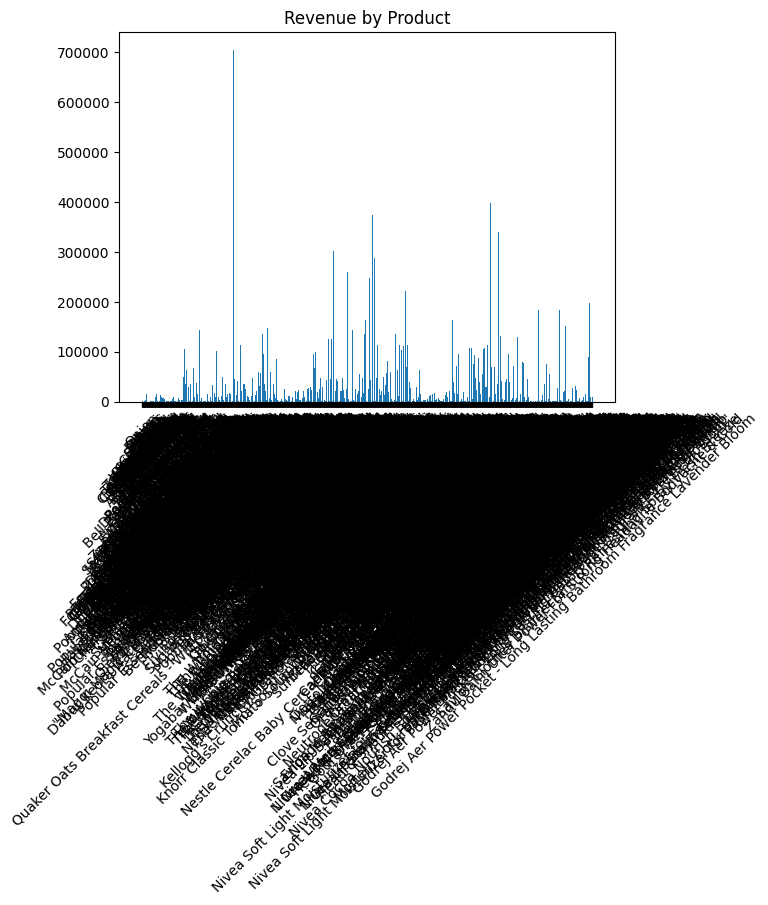

In [48]:
plt.figure()
plt.bar(df["name"], df["revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Product")
plt.show()

### Revenue Concentration

Analyzing dependency on top-performing products (Pareto analysis).

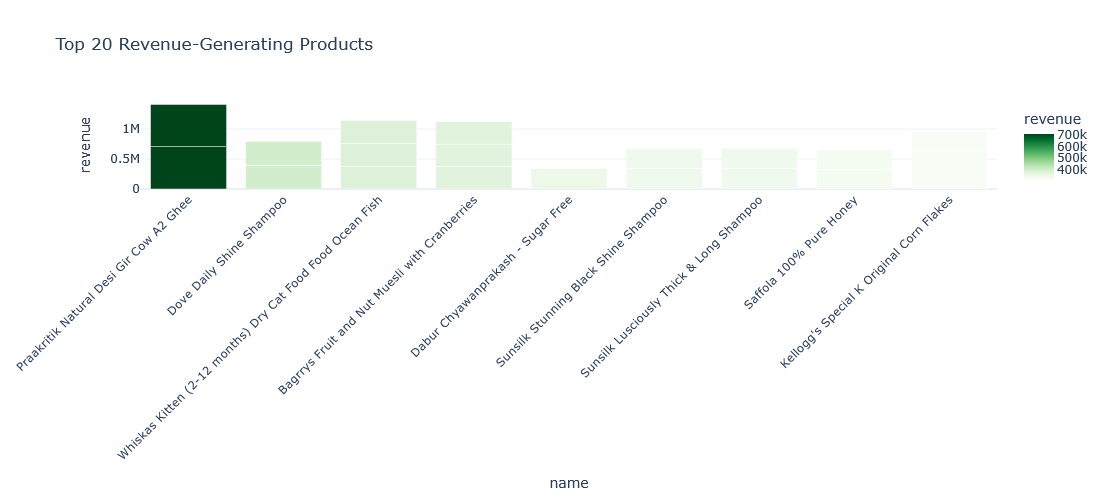

In [21]:
# Revenue concentration 
df_sorted = df.sort_values('revenue', ascending=False).copy()
df_sorted['cumulative_revenue'] = df_sorted['revenue'].cumsum()
df_sorted['revenue_pct'] = df_sorted['cumulative_revenue'] / df_sorted['revenue'].sum() * 100

pareto_products = len(df_sorted[df_sorted['revenue_pct'] <= 80])
total_products = len(df)

# Visualize
fig = px.bar(
    df_sorted.head(20), x='name', y='revenue',
    title=' Top 20 Revenue-Generating Products',
    color='revenue', color_continuous_scale='Greens'
)
fig.update_layout(template='plotly_white', xaxis_tickangle=-45, height=500)
fig.show()

In [23]:
# Summary statistics
summary_data = {
    'Metric': ['Total Revenue', 'Products Analyzed', 'Avg Revenue/Product', 'Stock-out Risk', 'Over-Discounted', 'Revenue Concentration'],
    'Value': [
        f'₹{df["revenue"].sum():,.0f}',
        f'{len(df):,}',
        f'₹{df["revenue"].mean():,.0f}',
        f'{len(df[df["availableQuantity"] < df["quantity"]])} products',
        f'{len(df[(df["discountPercent"] > 15) & (df["quantity"] < 5)])} products',
        'Top 20% = 80% revenue'
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{'text-align': 'center'}).background_gradient(cmap='RdYlGn', axis=None))

,Metric,Value
0,Total Revenue,"₹122,274,328"
1,Products Analyzed,"3,732"
2,Avg Revenue/Product,"₹32,764"
3,Stock-out Risk,3392 products
4,Over-Discounted,37 products
5,Revenue Concentration,Top 20% = 80% revenue


## Problem 4: Which products are overpriced or underpriced?

In [43]:
df[["name", "price_per_gram"]].sort_values(by="price_per_gram", ascending=False).head(15)

,name,price_per_gram
3273,Maybelline New York Colossal Kajal Super Black,inf
2840,Maybelline New York Colossal Kajal Black,inf
3184,Maybelline New York Colossal Kajal Black,inf
2929,Maybelline New York Colossal Kajal Super Black,inf
1120,Everest Saffron Kesar,120.0000
606,Everest Saffron Kesar,120.0000
3312,Nivea Lip Balm Soft Rose for 24h Moisture with...,37.0000
2968,Nivea Lip Balm Soft Rose for 24h Moisture with...,37.0000
2811,Nivea Lip Balm Original Care for 24h Moisture ...,28.0000
3155,Nivea Lip Balm Original Care for 24h Moisture ...,28.0000


In [28]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,Discounted-Amount,revenue,price_per_gram
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1,400,2100,2.500000
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1,700,3500,4.200000
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1,800,4300,87.931034
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100,300,170000,20.000000
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250,200,300000,5.600000


## Problem 5: Are we holding inefficient inventory?
* High stock + low sales = money blocked

In [44]:
df[["name", "availableQuantity", "quantity"]]

,name,availableQuantity,quantity
0,Onion,3,1
1,Tomato Hybrid,3,1
2,Tender Coconut,3,1
3,Coriander Leaves,3,100
4,Ladies Finger,3,250
...,...,...,...
3727,Stayfree Secure Dry Cover Extra Large Sanitary...,0,7
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,0,100
3729,Whisper Bindazzz Night Sanitary Pads XL Plus,0,15
3730,Fine Life Cotton Balls,0,50


## Problem 6: Is there abnormal ordering behavior?

In [46]:
df.sort_values(by="quantity", ascending =False)[["name", "quantity"]]

,name,quantity
2817,Savlon Moisture Shield Germ Protection Handwas...,1500
3161,Savlon Moisture Shield Germ Protection Handwas...,1500
1932,Pedigree Puppy Dry Dog Food Food Chicken & Milk,1200
1544,Pedigree Puppy Dry Dog Food Food Chicken & Milk,1200
2320,Pedigree Puppy Dry Dog Food Food Chicken & Milk,1200
...,...,...
2840,Maybelline New York Colossal Kajal Black,0
1120,Everest Saffron Kesar,0
2929,Maybelline New York Colossal Kajal Super Black,0
3184,Maybelline New York Colossal Kajal Black,0


## 7. Problem: Are we losing profit due to over-discounting?

* Some products might be selling well even without heavy discounts → unnecessary margin loss.

In [49]:
df[["name", "mrp", "discountedSellingPrice", "discountPercent", "quantity"]]

,name,mrp,discountedSellingPrice,discountPercent,quantity
0,Onion,25.0,21.0,16,1
1,Tomato Hybrid,42.0,35.0,16,1
2,Tender Coconut,51.0,43.0,15,1
3,Coriander Leaves,20.0,17.0,15,100
4,Ladies Finger,14.0,12.0,14,250
...,...,...,...,...,...
3727,Stayfree Secure Dry Cover Extra Large Sanitary...,42.0,41.0,2,7
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,105.0,89.0,15,100
3729,Whisper Bindazzz Night Sanitary Pads XL Plus,185.0,185.0,0,15
3730,Fine Life Cotton Balls,60.0,60.0,0,50


## 8. Problem: Which products have low demand despite discounts?
* If a product has a good discount but still low sales → poor product-market fit

In [53]:
low_demand = df[(df["discountPercent"] > 14) & (df["quantity"] <= 1)]

low_demand = low_demand.sort_values(by="discountPercent", ascending=False)

low_demand[["name", "discountPercent", "quantity"]]

,name,discountPercent,quantity
2323,Kelloggs Chocos - Moons & Stars,40,1
1935,Kelloggs Chocos - Moons & Stars,40,1
1547,Kelloggs Chocos - Moons & Stars,40,1
1182,Epigamia Almond Milk Unsweetened Dairy Free,33,1
1311,Epigamia Almond Milk Unsweetened Dairy Free,33,1
1206,Dlicia Whip Topping Bottle,27,1
898,Dlicia Whip Topping Bottle,27,1
384,Dlicia Whip Topping Bottle,27,1
1335,Dlicia Whip Topping Bottle,27,1
2744,Britannia Good Day Cashew Cookies,25,1


## 9. Problem: Is demand skewed (dependency on few products)?

- If most sales come from few products → risky business

In [54]:
df["revenue_share"] = df["revenue"] / df["revenue"].sum()
df[["name", "revenue", "revenue_share"]].sort_values(by="revenue", ascending=False)

,name,revenue,revenue_share
877,Praakritik Natural Desi Gir Cow A2 Ghee,704700.0,0.005763
363,Praakritik Natural Desi Gir Cow A2 Ghee,704700.0,0.005763
2931,Dove Daily Shine Shampoo,397800.0,0.003253
3275,Dove Daily Shine Shampoo,397800.0,0.003253
2192,Whiskas Kitten (2-12 months) Dry Cat Food Food...,381700.0,0.003122
...,...,...,...
2929,Maybelline New York Colossal Kajal Super Black,0.0,0.000000
3273,Maybelline New York Colossal Kajal Super Black,0.0,0.000000
1120,Everest Saffron Kesar,0.0,0.000000
3606,Cherry Blossom Liquid Shoe Polish Neutral,0.0,0.000000


## 10. Problem: Is product packaging inefficient?

* Different weights → inconsistent value perception

In [55]:
df[["name", "weightInGms", "price_per_gram"]]

,name,weightInGms,price_per_gram
0,Onion,1000,0.0250
1,Tomato Hybrid,1000,0.0420
2,Tender Coconut,58,0.8793
3,Coriander Leaves,100,0.2000
4,Ladies Finger,250,0.0560
...,...,...,...
3727,Stayfree Secure Dry Cover Extra Large Sanitary...,406,0.1034
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,100,1.0500
3729,Whisper Bindazzz Night Sanitary Pads XL Plus,870,0.2126
3730,Fine Life Cotton Balls,50,1.2000


## 11. Problem: Bulk buying behavior risk

- Very high quantity orders may:

    - Cause stockouts
    - Indicate reseller activity

In [56]:
bulk_orders = df[df["quantity"] > 50]
bulk_orders[["name", "quantity"]]

,name,quantity
3,Coriander Leaves,100
4,Ladies Finger,250
6,Lemon,200
8,Capsicum Green,250
9,Chilli Green,100
...,...,...
3716,Dabur Nature Care Isabgol - Double Action,100
3719,Epigamia Fruit Yogurt Strawberry,75
3720,Dettol Effective Protection Antiseptic Liquid,250
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,100


## 12. Problem: Poor inventory allocation

- Same available quantity for all products despite different demand

In [57]:
df[["name", "availableQuantity", "quantity"]]

,name,availableQuantity,quantity
0,Onion,3,1
1,Tomato Hybrid,3,1
2,Tender Coconut,3,1
3,Coriander Leaves,3,100
4,Ladies Finger,3,250
...,...,...,...
3727,Stayfree Secure Dry Cover Extra Large Sanitary...,0,7
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,0,100
3729,Whisper Bindazzz Night Sanitary Pads XL Plus,0,15
3730,Fine Life Cotton Balls,0,50


## 13. Problem: Price sensitivity analysis missing
We don’t know how sensitive customers are to price changes

In [58]:
df[["name", "discountPercent", "quantity"]]

,name,discountPercent,quantity
0,Onion,16,1
1,Tomato Hybrid,16,1
2,Tender Coconut,15,1
3,Coriander Leaves,15,100
4,Ladies Finger,14,250
...,...,...,...
3727,Stayfree Secure Dry Cover Extra Large Sanitary...,2,7
3728,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,15,100
3729,Whisper Bindazzz Night Sanitary Pads XL Plus,0,15
3730,Fine Life Cotton Balls,0,50


## 14. Problem: Category-level inefficiency

- All products belong to one category → no diversification

In [61]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity',
       'Discounted-Amount', 'revenue', 'price_per_gram', 'revenue_share'],
      dtype='object')

In [62]:
df["Category"].value_counts()

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Paan Corner              344
Personal Care            344
Home & Cleaning          194
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

In [63]:
df["outOfStock"].value_counts()

outOfStock
False    3279
True      453
Name: count, dtype: int64

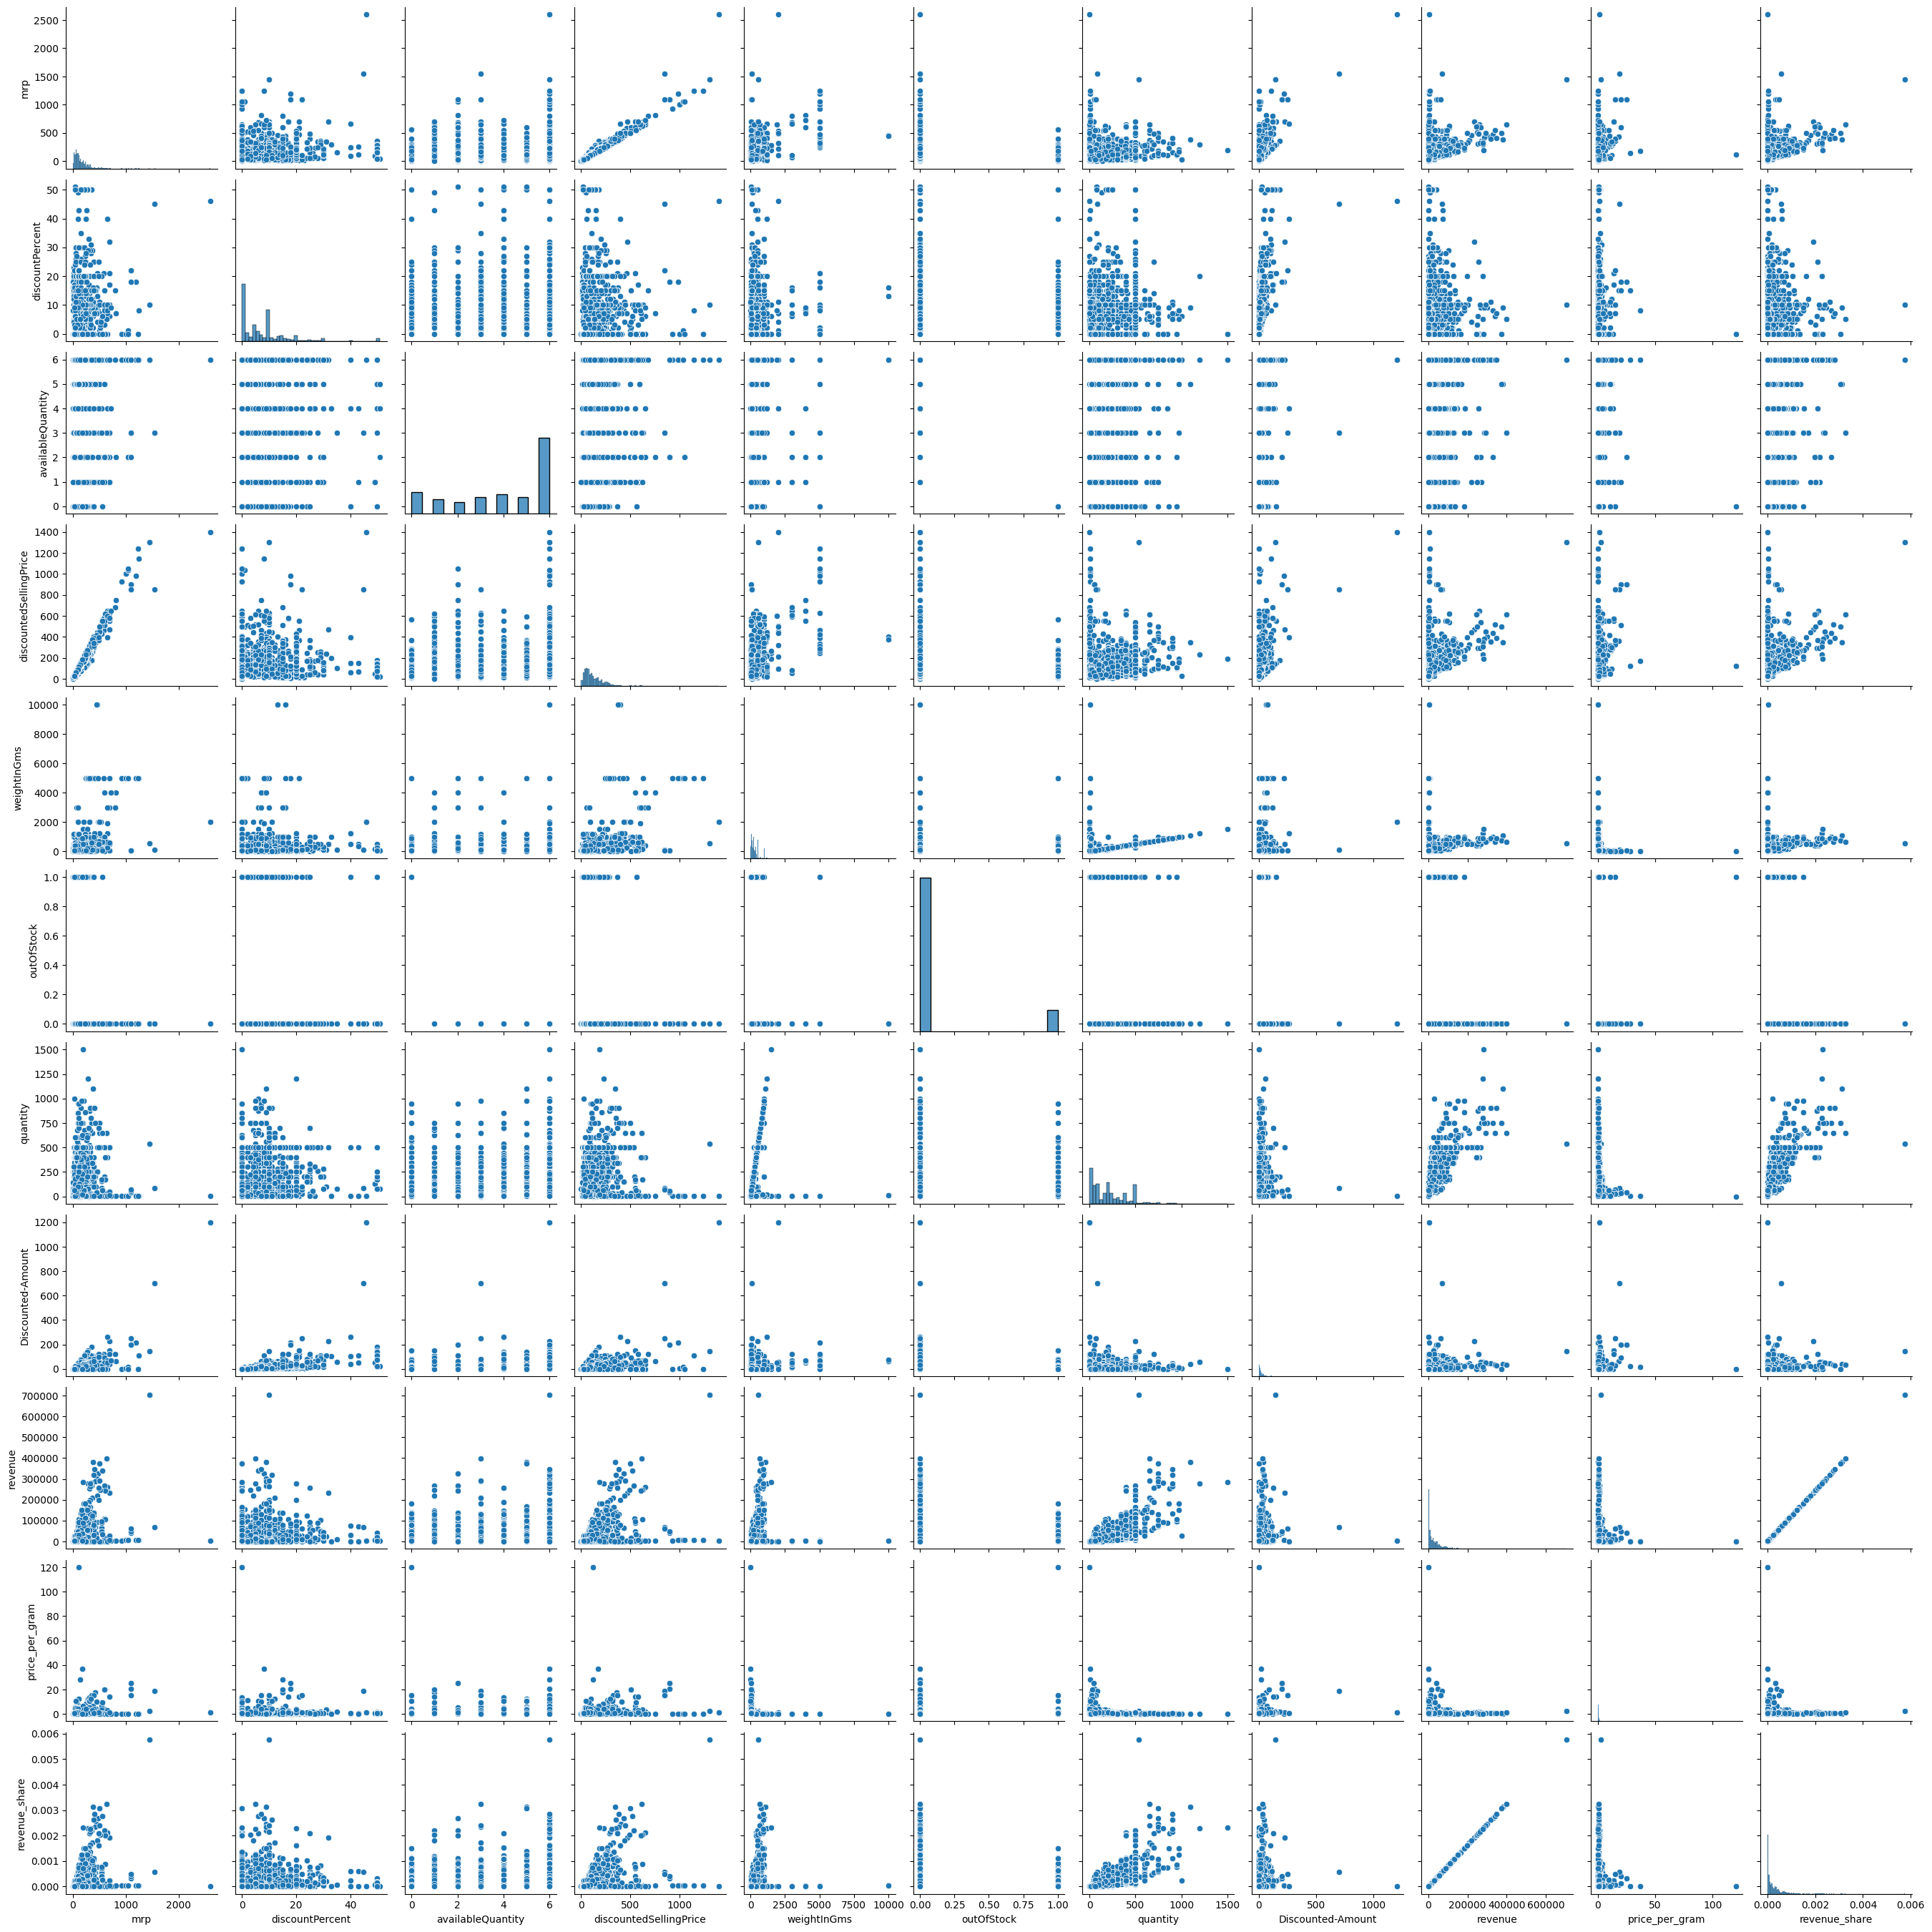

In [64]:
import seaborn as sns

sns.pairplot(df)